## Data science project on predicting game sales

There are various factors which would affect game sales whether it is the year games were sold due to access to PC or consoles being limited in the past or if the games scores rated by players where a good game naturally sells well. We will take a deeper dive into the various fields in the data to see how these correlate and create a model to predict future game sales on various factors.

Key things to note about the limitations of this dataset:
- The dataset only covers up to December 2016.
- We will also ignore the price of games as this fluctuates over time, we will be looking at sales figures instead which are presented in millions.
- We will not use other sales columns to predict global sales as this would be useless.
- We will not look at the number of critic and user reviews as again this wouldn't be available until after the fact where prediction is no longer helpful.

First we want to import the dataset and take a look at how the data looks like, let's import this using pyspark to test it is working I have recently installed this for personal learning. We can convert this back into a pandas data frame after.

In [59]:
from pyspark.context import SparkContext
from pyspark.sql.session import SparkSession
import pandas as pd

sc = SparkContext.getOrCreate()
spark = SparkSession(sc)

df = spark.read.csv(
                    "Video_Games_Sales_as_at_22_Dec_2016.csv", 
                    header=True, mode="DROPMALFORMED", 
                    inferSchema=True
                    )

game_df = df.select("*").toPandas()

game_df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,None,NaN,None,None
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,None,NaN,None,None


Now let's take a look at the statistics of the dataset let's see total rows and see if there are anything missing.

In [62]:
display(game_df.info())

display(game_df.describe())

display(game_df.isnull().sum())

game_df.loc[game_df['Name'].isnull()]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16719 non-null  object 
 3   Genre            16717 non-null  object 
 4   Publisher        16719 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(8), object(8)
memory usage: 2.0+ MB


None

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000
mean,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,162.229908
std,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,561.282326
min,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,24.000000
75%,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,81.000000
max,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


Name                  2
Platform              0
Year_of_Release       0
Genre                 2
Publisher             0
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Developer          6623
Rating             6769
dtype: int64

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
659,None,GEN,1993,None,Acclaim Entertainment,1.78,0.53,0.00,0.08,2.39,NaN,NaN,None,NaN,None,None
14246,None,GEN,1993,None,Acclaim Entertainment,0.00,0.00,0.03,0.00,0.03,NaN,NaN,None,NaN,None,None


Before we drop anything let's take a look at the correlations between the numerical values.

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
NA_Sales,1.000000,0.765336,0.449598,0.638654,0.941010,0.240755,0.295413,0.246429
EU_Sales,0.765336,1.000000,0.435068,0.722796,0.901239,0.220752,0.277533,0.283360
JP_Sales,0.449598,0.435068,1.000000,0.291096,0.612300,0.152593,0.180219,0.075638
Other_Sales,0.638654,0.722796,0.291096,1.000000,0.749242,0.198554,0.251639,0.238982
Global_Sales,0.941010,0.901239,0.612300,0.749242,1.000000,0.245471,0.303571,0.265012
Critic_Score,0.240755,0.220752,0.152593,0.198554,0.245471,1.000000,0.425504,0.264376
Critic_Count,0.295413,0.277533,0.180219,0.251639,0.303571,0.425504,1.000000,0.362334
User_Count,0.246429,0.283360,0.075638,0.238982,0.265012,0.264376,0.362334,1.000000


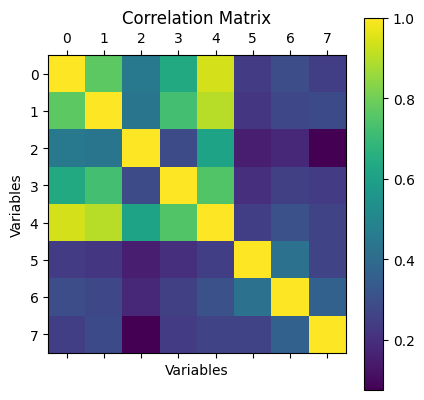

In [63]:
display(game_df.corr(numeric_only=True))

#Seems like global sales is most correlated with critic count, user score, and user count. Let's visualize these relationships in a correlation matrix.

import matplotlib.pyplot as plt

plt.matshow(game_df.corr(numeric_only=True))
plt.colorbar()
plt.xlabel('Variables')
plt.ylabel('Variables')
plt.title('Correlation Matrix')
plt.show()

Seems like there are some issues with 2 rows of data with almost no values across all columns, let's remove them as they are not helpful.

We also want to remove any columns which are related to the independent variable Global Sales e.g. EU_Sales, JP_Sales etc and also variables which we won't have at the time of prediction e.g. we won't have number of critic and user reviews until sales has already stabilised and prediction is no longer helpful.

In [64]:
game_df = game_df.dropna(subset=['Name'])

#game_df = game_df.drop(columns=['Name', 'Year_of_Release', 'Genre', 'Rating', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'])

game_df = game_df.drop(columns=['Name', 'Year_of_Release', 'Genre', 'Rating', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Critic_Count', 'User_Count'])

display(game_df.isnull().sum())

Platform           0
Publisher          0
Global_Sales       0
Critic_Score    8580
User_Score      6702
Developer       6621
dtype: int64

There are also various values of for 'blank' values instead of NaN values let's replace those to make sure these aren't detected as string values and convert them into floats.

In [65]:
import numpy as np

game_df = game_df.replace('None', np.nan).replace('N/A', np.nan).replace('nan', np.nan).replace([None], np.nan).replace('tbd', np.nan)

#Go through the columns and check for null values and add to the replace list above if any are found.
display(game_df['Developer'].unique())

game_df = game_df.apply(pd.to_numeric, errors='ignore')

display(game_df.info())



array(['Nintendo', nan, 'Good Science Studio', ..., 'Big Red Software',
       'Atomic Games', 'Interchannel-Holon'], shape=(1697,), dtype=object)

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Platform      16717 non-null  object 
 1   Publisher     16663 non-null  object 
 2   Global_Sales  16717 non-null  float64
 3   Critic_Score  8137 non-null   float64
 4   User_Score    7590 non-null   float64
 5   Developer     10096 non-null  object 
dtypes: float64(3), object(3)
memory usage: 914.2+ KB


C:\Users\Michael Choi\AppData\Local\Temp\ipykernel_15380\2590051860.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  game_df = game_df.apply(pd.to_numeric, errors='ignore')


None

Seems like the correlation between the columns with missing values are relatively weak and the amount of columns with empty fields make up almost half of the dataset so imputing such large amount of values won't give helpful results so let's drop them for columns we are interested in using.

In [66]:
game_df = game_df.dropna()

display(game_df.isnull().sum())

display(game_df.describe())

Platform        0
Publisher       0
Global_Sales    0
Critic_Score    0
User_Score      0
Developer       0
dtype: int64

,Global_Sales,Critic_Score,User_Score
count,7009.000000,7009.000000,7009.000000
mean,0.767719,70.263233,7.183721
std,1.941316,13.872099,1.439952
min,0.010000,13.000000,0.500000
25%,0.110000,62.000000,6.500000
50%,0.290000,72.000000,7.500000
75%,0.750000,80.000000,8.200000
max,82.530000,98.000000,9.600000


This have already tried the Linear regression model which had an R^2 score of 0.33 which is on the lower end of acceptable (0.3-0.7), this time we have kept some categorical values which could help so let's use the random forest model which can use a mixture of categorical and numerical values but remember we will need to convert the categorical data into numerical data before this model can be used.

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

#Use LabelEncoder to convert categorical variables to numerical values
label_encoder = LabelEncoder()

for col in game_df.select_dtypes(include=['object']).columns:
    game_df[col] = label_encoder.fit_transform(game_df[col])

x = game_df.drop("Global_Sales", axis=1)

y = game_df["Global_Sales"]

display(x)

display(y)

#print(x_train.head())

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

regressor = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    oob_score=True
)

regressor.fit(x_train, y_train)

print("Out of Bag score:", regressor.oob_score_)

y_pred = regressor.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("R^2 Score:", r2)

,Platform,Publisher,Critic_Score,User_Score,Developer
0,12,166,76.0,8.0,785
2,12,166,82.0,8.3,785
3,12,166,80.0,8.0,785
6,2,166,89.0,8.5,785
7,12,166,58.0,6.6,785
...,...,...,...,...,...
16677,3,152,81.0,8.8,265
16696,5,128,80.0,7.6,630
16700,5,57,61.0,5.8,101
16706,5,249,60.0,7.2,1027


0        82.53
2        35.52
3        32.77
6        29.80
7        28.92
         ...  
16677     0.01
16696     0.01
16700     0.01
16706     0.01
16709     0.01
Name: Global_Sales, Length: 7009, dtype: float64

Out of Bag score: 0.2863546798219556
Mean Squared Error: 1.4911184938457624
R^2 Score: 0.3858584983983928


Seems like including additional categorical fields of Platform, Developer and publisher has increased the accuracy of the model to 0.39 which is a reasonable considering sales and game industry is highly volatile. We can also take a look at how the different dependent variables affect the independent variables (Sales).

In [ ]:
myClassifiers = pd.Series(regressor.feature_importances_, index=x_train.columns)

print(myClassifiers.sort_values(ascending=False))

Critic_Score    0.303341
Developer       0.289621
User_Score      0.178565
Platform        0.150557
Publisher       0.077916
dtype: float64
